# **DETEKSI KENDARAAN BERODA BERDASARKAN DATA CITRA DENGAN MENGGUNAKAN YOLOV8**
-----
Hasthabrata Christopher Liatna - 2206824741

# **Import Libraries**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import os
import cv2
import glob
import yaml
import random
import pathlib
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm.notebook import trange, tqdm
from IPython.display import Image, Video
from IPython.display import Image, display
from sklearn.metrics import precision_score, recall_score
!wandb disabled
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
W&B disabled.


# **Input Data**

In [ ]:
!unzip /content/Pro_TK1.zip -d Pro_TK1

Archive:  /content/Pro_TK1.zip
   creating: Pro_TK1/Pro_TK1/
   creating: Pro_TK1/Pro_TK1/TestVideo/
  inflating: Pro_TK1/Pro_TK1/TestVideo/TrafficPolice.mp4  
   creating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/dataset.yaml  
   creating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/
   creating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg  
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg  
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg  
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg  
  inflating: Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images/08c8b73e0c2e296e_jpg.rf.7IkYAam

# **EDA**

In [ ]:
train_path = '/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/train/images'
val_path = '/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/valid/images'
test_path = '/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/images'

yaml_content = f"""
test: {test_path}
train: {train_path}
val: {val_path}

nc: 5  # Number of classes
names: ['Ambulans', 'Bis', 'Mobil', 'Motor', 'Truk']
"""
output_path = 'data.yaml'
with open(output_path, 'w') as file:
    file.write(yaml_content)
color_code = "\033[38;2;163;196;243m"
reset_code = "\033[0m"
print(f"{color_code}YAML file has been saved to {output_path}{reset_code}")

YAML file has been saved to data.yaml


In [ ]:
output_path = 'data.yaml'
with open(output_path, 'r') as file:
    data = yaml.safe_load(file)
class_names = data['names']
print(f"{color_code}Class Names:{reset_code} {class_names}")

Class Names: ['Ambulans', 'Bis', 'Mobil', 'Motor', 'Truk']


In [ ]:
import os
import random
from PIL import Image
images_folder = '/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/train/images'
image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_image = random.choice(image_files)
random_image_path = os.path.join(images_folder, random_image)
image = Image.open(random_image_path)
image_size = image.size
image_mode = image.mode
num_channels = image.layers if hasattr(image, 'layers') else len(image.getbands())
print(f"Random Image: {random_image}")
print(f"Image Size: {image_size}")
print(f"Image Mode (Channels): {image_mode}")
print(f"Number of Channels: {num_channels}")

Random Image: 6b0ff20bea33a627_jpg.rf.CWb0AxkbI75N8WGzv9Cv.jpg
Image Size: (416, 416)
Image Mode (Channels): RGB
Number of Channels: 3


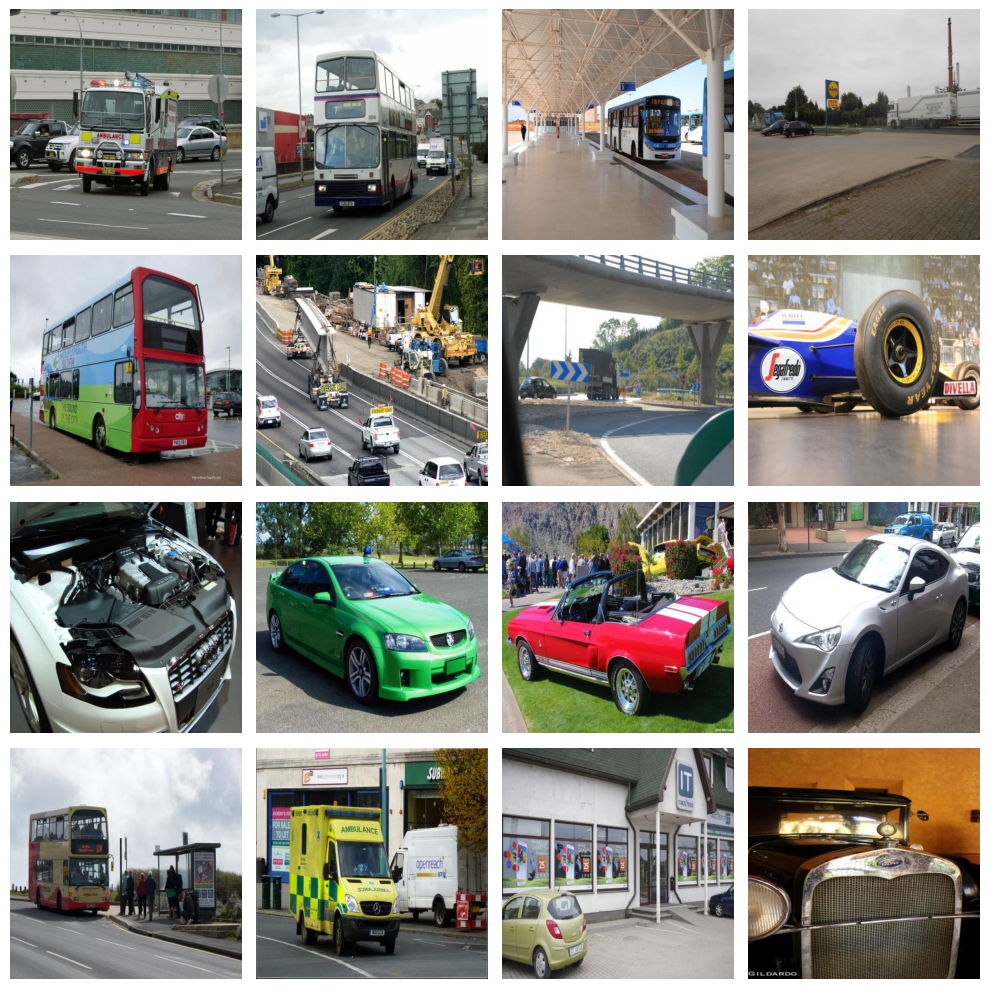

In [ ]:
image_files = [f for f in os.listdir(train_path) if f.endswith('.jpg')]
selected_images = random.sample(image_files, 16)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img_path = os.path.join(train_path, selected_images[i])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

# **Pelatihan Model**

In [ ]:
finalmodel = YOLO('yolov8n.yaml').load('yolov8n.pt')
Result_finalmodel = finalmodel.train(data="/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/dataset.yaml",epochs=100, imgsz=416, batch=16, lr0=0.001, dropout=0.1)

100%|██████████| 6.25M/6.25M [00:00<00:00, 341MB/s]

Transferred 355/355 items from pretrained weights
Ultralytics 8.3.138 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

100%|██████████| 755k/755k [00:00<00:00, 104MB/s]

Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

YOLOv8n summary: 129 layers, 3,011,823 parameters, 3,011,807 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

    100/100       2.8G     0.4585     0.3505     0.9034         21        416: 100%|██████████| 55/55 [00:07<00:00,  6.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]

                   all        250        454      0.606       0.58      0.572      0.444



100 epochs completed in 0.289 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.138 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]


                   all        250        454      0.645      0.533      0.598      0.446
              Ambulans         50         64      0.634      0.875      0.873      0.757
                   Bis         30         46      0.583      0.609      0.627      0.511
                 Mobil         90        238      0.652      0.347      0.451      0.315
                 Motor         42         46      0.636      0.565      0.622      0.358
                  Truk         38         60      0.719      0.267       0.42       0.29
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs/detect/train


# **Evaluasi Model**

In [ ]:
best_model = YOLO('/content/runs/detect/train/weights/best.pt')
metrics = best_model.val(split = 'test')

Ultralytics 8.3.138 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 510.7±150.4 MB/s, size: 26.1 KB)


val: Scanning /content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/labels... 126 images, 0 backgrounds, 0 corrupt: 100%|██████████| 126/126 [00:00<00:00, 2032.51it/s]

val: New cache created: /content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]


                   all        126        258      0.776      0.633      0.719      0.532
              Ambulans         18         18       0.72          1      0.995      0.926
                   Bis         22         38      0.825      0.744      0.824      0.613
                 Mobil         60        150      0.723       0.56      0.584      0.386
                 Motor         12         32      0.613      0.312      0.473      0.231
                  Truk         14         20          1      0.547      0.718      0.505
Speed: 1.6ms preprocess, 3.9ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/detect/val


In [ ]:
from PIL import Image
image_dir = '/content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/test'
image_files = [os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith('.jpg')]
random_images = random.sample(image_files,k=0)
save_dir = '/content/yolo_results'
os.makedirs(save_dir, exist_ok=True)
for image_path in random_images:
    image = Image.open(image_path).convert('RGB')
    image_np = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    results = best_model.predict([image_np], save_dir=save_dir, imgsz=416, conf=0.5, iou=0.7)
    display(image)
    plot = results[0].plot()
    plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(plot))

In [ ]:
from google.colab import files
files.download("/content/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model = YOLO("/content/best.pt")

# Run validation (this assumes you have a valid `data.yaml` file)
metrics = model.val(data="/content/data.yaml")

Ultralytics 8.3.138 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 21.2MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 595.9±71.4 MB/s, size: 30.7 KB)



val: Scanning /content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/valid/labels... 250 images, 0 backgrounds, 0 corrupt: 100%|██████████| 250/250 [00:00<00:00, 1543.63it/s]

val: New cache created: /content/Pro_TK1/Pro_TK1/VehiclesDetectionDataset/valid/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:34<00:00,  2.13s/it]


                   all        250        454      0.645      0.532      0.598      0.447
              Ambulans         50         64      0.635      0.875      0.873      0.757
                   Bis         30         46      0.581      0.609      0.627      0.514
                 Mobil         90        238      0.652      0.346       0.45      0.315
                 Motor         42         46      0.637      0.565      0.622      0.359
                  Truk         38         60       0.72      0.267       0.42      0.289
Speed: 4.6ms preprocess, 125.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/val


# **Display Hasil**

In [ ]:
from IPython.display import HTML
from base64 import b64encode

output_path = '/content/runs/detect/predict/TrafficPolice.avi'

# Encode the video to display it in notebook
mp4 = open(output_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=640 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")
